In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D


In [ ]:
# To import data file from my PC to Colab
from google.colab import files
files = files.upload()

In [2]:
# To import data file from Colab to my notebook
data_df = pd.read_csv("challenge.txt", delimiter='\t', header=None)
data_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'challenge.txt'

In [8]:
data_df.info() # There is no null data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1000 non-null   float64
 1   1       1000 non-null   float64
 2   2       1000 non-null   float64
 3   3       1000 non-null   float64
 4   4       1000 non-null   float64
 5   5       1000 non-null   float64
 6   6       1000 non-null   float64
 7   7       1000 non-null   float64
 8   8       1000 non-null   float64
 9   9       1000 non-null   float64
dtypes: float64(10)
memory usage: 78.3 KB


In [9]:
data_df.describe()

,0,1,2,3,4,5,6,7,8,9
count,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,9.600000,16.000000,7.105427e-17,7.105427e-17,5.684342e-17,-8.526513e-17,-2.842171e-17,4.973799e-17,7.105427e-17,3.552714e-17
std,9.072724,15.027236,1.262376e+00,9.979960e-01,4.463174e-01,4.463174e-01,4.463174e-01,4.463174e-01,4.463174e-01,4.463174e-01
min,-1.998575,-2.334028,-2.539774e+00,-4.008339e+00,-1.849478e+00,-1.759452e+00,-1.861308e+00,-1.886905e+00,-2.126307e+00,-1.765256e+00
25%,0.309105,0.360104,-1.006501e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.299342,19.141101,1.612305e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,19.454824,21.241760,9.153497e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,22.692985,42.932004,4.036427e+00,7.424209e+00,1.787044e+00,1.883213e+00,1.836862e+00,1.803226e+00,1.886478e+00,1.823437e+00


In [10]:
# To find the number of 0 in each dimension
zero_numbers = []
for column in data_df.columns:
  zero_numbers.append(len(np.where(data_df.iloc[:, column]==0)[0]))
zero_numbers

[0, 0, 0, 600, 800, 800, 800, 800, 800, 800]

در 3 ستون اول دادهها یصفر وجود ندارد ولی در بقیه ستونها اکثر داده ها صفر هستند. با استفاده از پیرپلات وضعیت دو به دوی داده ها نسبت به یکدیگر را بررسی می کنیم. به وضوح ویژگی کلاسترینگ در داده ها مشاهده می شود.به وضوح دیده می شود که در فیچرهای 3 تا آخر توزیع داده ها به شدت ناهمگون است و اکثر داده های این فیچرها در حوالی صفر متمرکز هستند.  

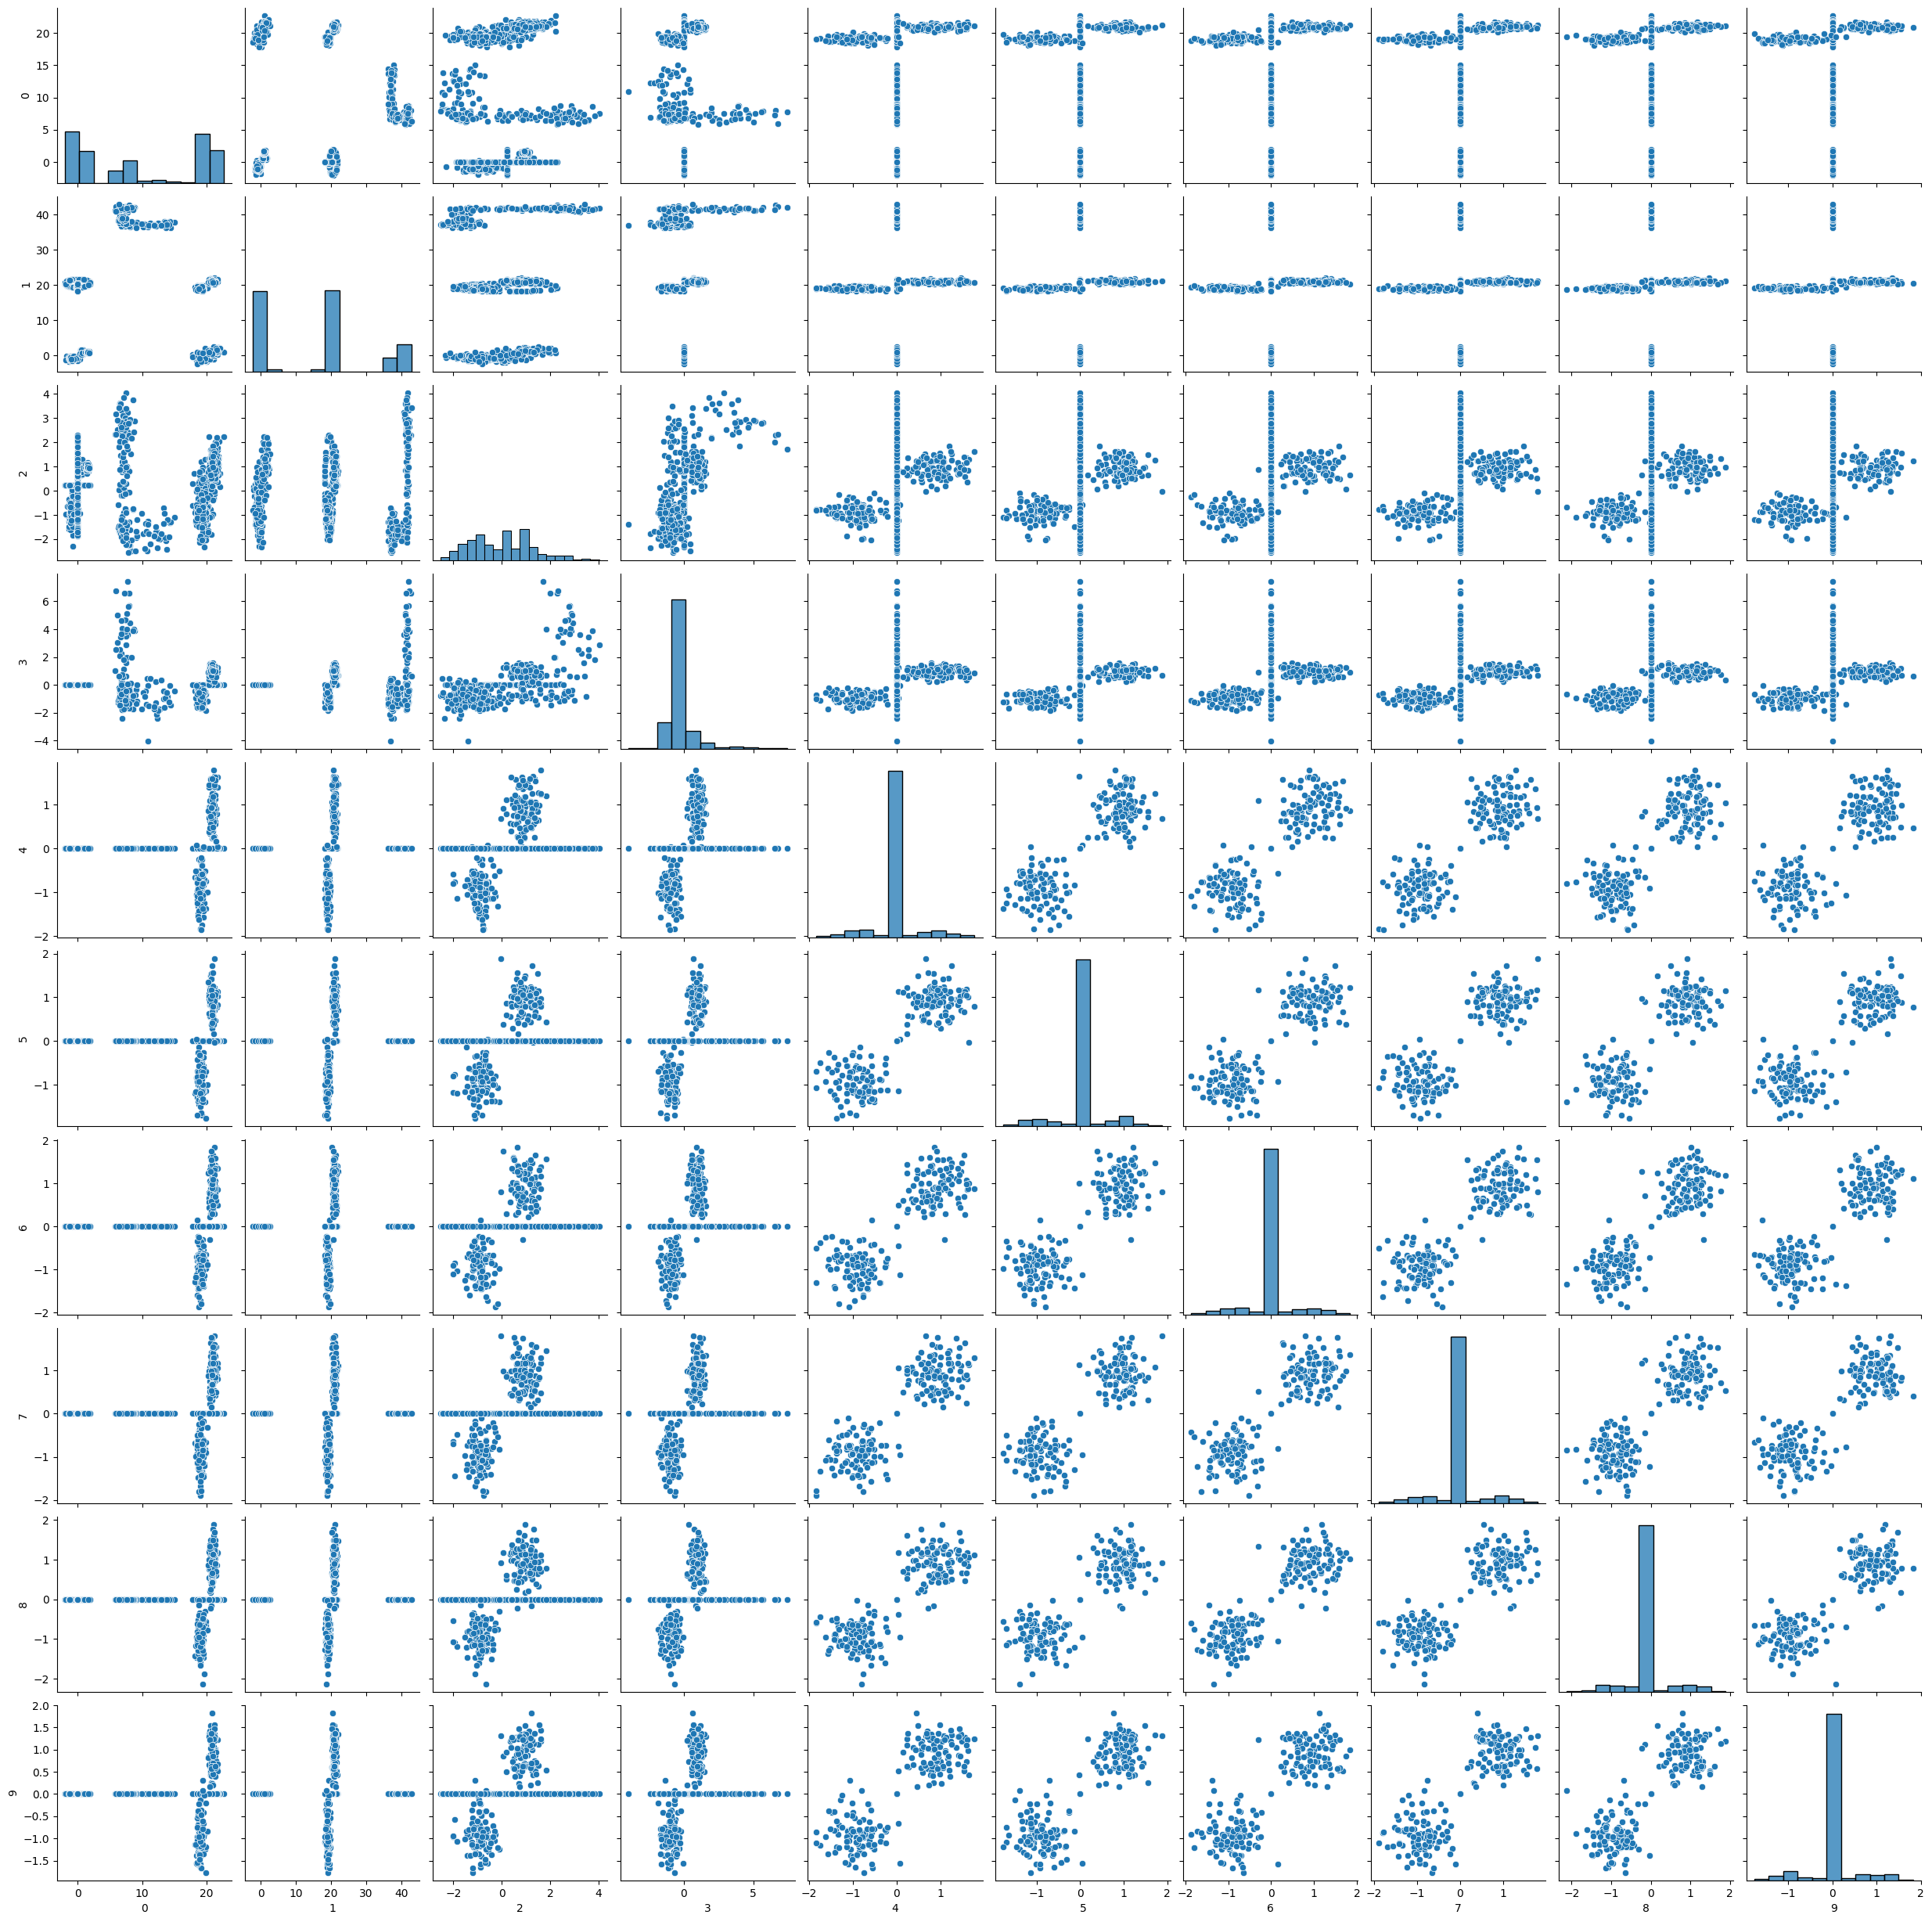

In [11]:
sns.pairplot(data_df)

به منظور بررسی بیشتر میتوان نمودار سه بعدی سه ستون اول را که داده های صفر ندارند را رسم نمود

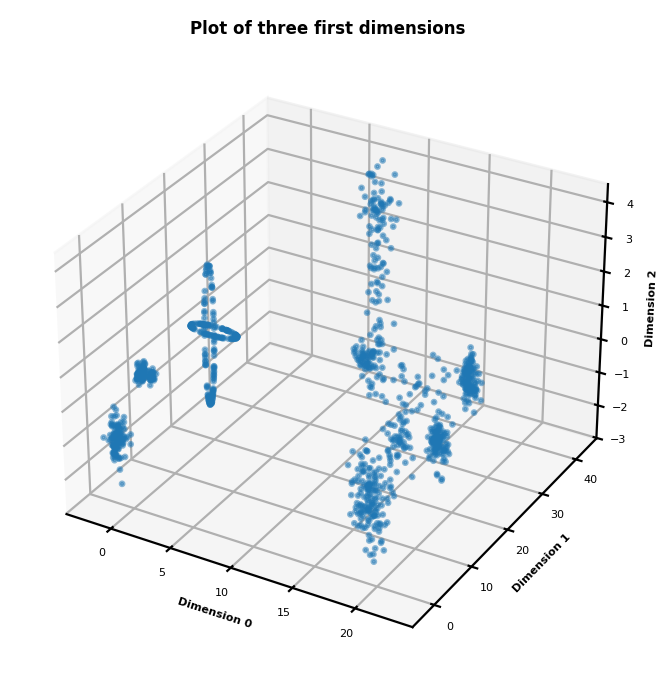

In [12]:
fig = plt.figure(figsize=(6, 4), dpi=200)
ax = fig.add_subplot(111, projection = "3d" )
ax.scatter(data_df.iloc[:, 0], data_df.iloc[:, 1], data_df.iloc[:, 2], s=2, alpha=0.5)

ax.set_xlabel("Dimension 0", fontsize=4, labelpad=-10, weight="bold")
ax.tick_params(axis='x', labelsize=4, pad=-3)

ax.set_ylabel("Dimension 1", fontsize=4, labelpad=-10, weight="bold")
ax.tick_params(axis='y', labelsize=4, pad=-3)

ax.set_zlabel("Dimension 2", fontsize=4, labelpad=-10, weight="bold")
ax.tick_params(axis='z', labelsize=4, pad=-3)

ax.set_title("Plot of three first dimensions"  , fontsize=6, loc="center", weight="bold");

میبینیم که 3 فیچر مهم اول هم ویژگی کلاسترینگ را نشان میدهند. با توجه به شکل داده ها حتی شاید بتوان فیچیسلکشن هم کرد ولی من اینجا فیراکسترکشن میکنم با پی سی ای

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [14]:
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data_df)
pca_2d = PCA(n_components=2)
pca_3d = PCA(n_components=3)

In [ ]:
# To transform the 10 dimensional original feature space to 2 & 3 lower dimension space
X_pca_2d = pca_2d.fit_transform(data_normalized)
X_pca_3d = pca_3d.fit_transform(data_normalized)
print(f" The shape of 2d reduced features is: {(X_pca_2d.shape)} and 3d is: {(X_pca_3d.shape)}")

 The shape of 2d reduced features is: (1000, 2) and 3d is: (1000, 3)


In [ ]:
for pca in pca_2d.explained_variance_ratio_:
  print(f"{pca:0.3f}")

0.569
0.120


In [ ]:
for pca in pca_3d.explained_variance_ratio_:
  print(f"{pca:0.3f}")

0.569
0.120
0.106


As it can see above, approximately 0.689 and 0.795 of variance (information) are captured using 2d and 3d Principal Components Analysis, respectively. Know its time to plot the features of reduced space.   

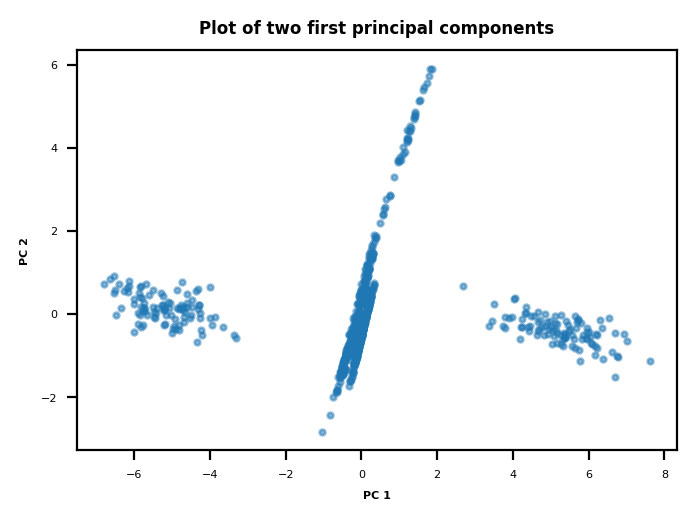

In [ ]:
fig = plt.figure(figsize=(3, 2), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])
ax.plot(X_pca_2d[:, 0], X_pca_2d[:, 1], "o", markersize=2, alpha=0.5)
ax.set_title("Plot of two first principal components"  , fontsize=6, loc="center", weight="bold")

ax.set_xlabel("PC 1", fontsize=4, weight="bold")
ax.tick_params(axis='x', labelsize=4)

ax.set_ylabel("PC 2", fontsize=4, weight="bold")
ax.tick_params(axis='y', labelsize=4);


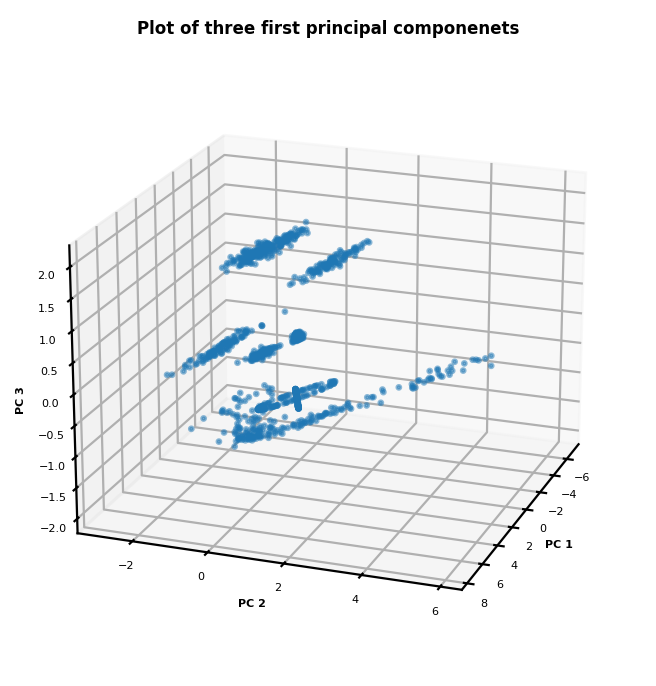

In [ ]:
fig = plt.figure(figsize=(6, 4), dpi=200)
ax = fig.add_subplot(111, projection = "3d" )
ax.view_init(20, 20)
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], s=2, alpha=0.5)

ax.set_xlabel("PC 1", fontsize=4, labelpad=-10, weight="bold")
ax.tick_params(axis='x', labelsize=4, pad=-3)

ax.set_ylabel("PC 2", fontsize=4, labelpad=-10, weight="bold")
ax.tick_params(axis='y', labelsize=4, pad=-3)

ax.set_zlabel("PC 3", fontsize=4, labelpad=-10, rotation=90, weight="bold")
ax.tick_params(axis='z', labelsize=4, pad=-3)

ax.set_title("Plot of three first principal componenets"  , fontsize=6, loc="center", weight="bold");

Now t_SNE Method will be used for Dimensionality Reduction. As you Know this method is rely on preserving neighboring points from mapping high dimension to a lower one.

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne_2d = TSNE(n_components=2, perplexity = 30, random_state = 42, n_iter = 1000)
tsne_3d = TSNE(n_components=3, perplexity = 30, random_state = 42, n_iter = 1000)

In [ ]:
# To transform the 10 dimensional original feature space to 2 & 3 lower dimension space with t_SNE
X_tsne_2d = tsne_2d.fit_transform(data_normalized)
X_tsne_3d = tsne_3d.fit_transform(data_normalized)
print(f" The shape of 2d reduced features is: {(X_tsne_2d.shape)} and 3d is: {(X_tsne_3d.shape)}")

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


 The shape of 2d reduced features is: (1000, 2) and 3d is: (1000, 3)


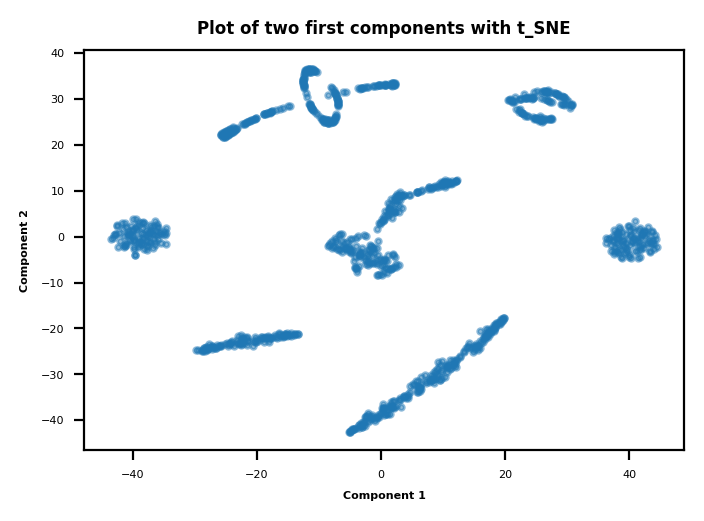

In [ ]:
fig = plt.figure(figsize=(3, 2), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])
ax.plot(X_tsne_2d[:, 0], X_tsne_2d[:, 1], "o", markersize=2, alpha=0.5)
ax.set_title("Plot of two first components with t_SNE"  , fontsize=6, loc="center", weight="bold")

ax.set_xlabel("Component 1", fontsize=4, weight="bold")
ax.tick_params(axis='x', labelsize=4)

ax.set_ylabel("Component 2", fontsize=4, weight="bold")
ax.tick_params(axis='y', labelsize=4);

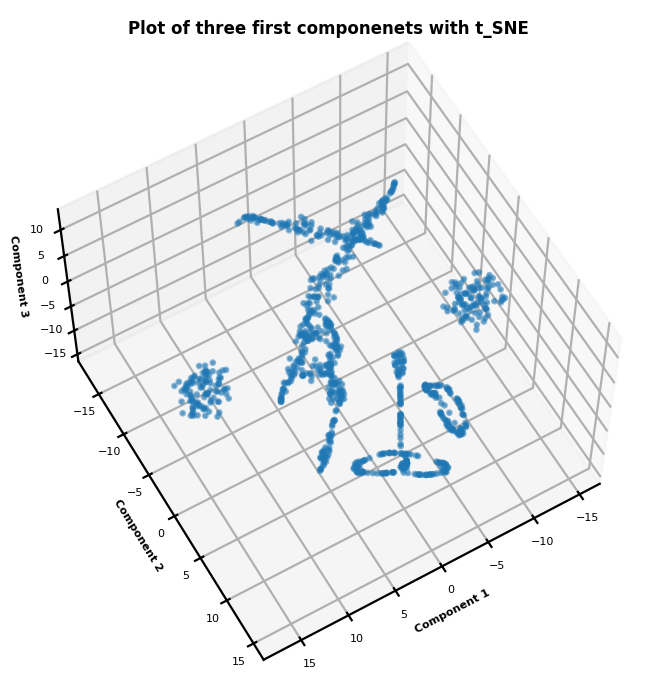

In [ ]:
fig = plt.figure(figsize=(6, 4), dpi=200)
ax = fig.add_subplot(111, projection = "3d" )
ax.view_init(60, 60)
ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], s=2, alpha=0.5)

ax.set_xlabel("Component 1", fontsize=4, labelpad=-10, weight="bold")
ax.tick_params(axis='x', labelsize=4, pad=-3)

ax.set_ylabel("Component 2", fontsize=4, labelpad=-10, weight="bold")
ax.tick_params(axis='y', labelsize=4, pad=-3)

ax.set_zlabel("Component 3", fontsize=4, labelpad=-10, rotation=90, weight="bold")
ax.tick_params(axis='z', labelsize=4, pad=-3)

ax.set_title("Plot of three first componenets with t_SNE"  , fontsize=6, loc="center", weight="bold");

Following UMAP method will be used for dimensionality reduction, UMAP tries to preserve local structures like t_SNE method but it focuses on some global structures too.

In [ ]:
import umap.umap_ as umap

In [ ]:
umap_2d = umap.UMAP(n_components=2, random_state = 42)
umap_3d = umap.UMAP(n_components=3, random_state = 42)

In [ ]:
# To transform 10 dimensional original feature space to 2 & 3 lower dimension space with UMAP
X_umap_2d = umap_2d.fit_transform(data_normalized)
X_umap_3d = umap_3d.fit_transform(data_normalized)
print(f" The shape of 2d reduced features is: {(X_umap_2d.shape)} and 3d is: {(X_umap_3d.shape)}")

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 The shape of 2d reduced features is: (1000, 2) and 3d is: (1000, 3)


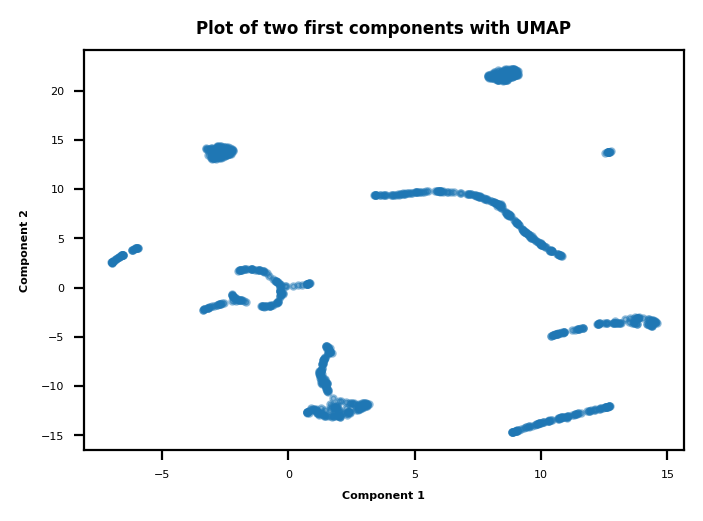

In [ ]:
fig = plt.figure(figsize=(3, 2), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])
ax.plot(X_umap_2d[:, 0], X_umap_2d[:, 1], "o", markersize=2, alpha=0.5)
ax.set_title("Plot of two first components with UMAP"  , fontsize=6, loc="center", weight="bold")

ax.set_xlabel("Component 1", fontsize=4, weight="bold")
ax.tick_params(axis='x', labelsize=4)

ax.set_ylabel("Component 2", fontsize=4, weight="bold")
ax.tick_params(axis='y', labelsize=4);

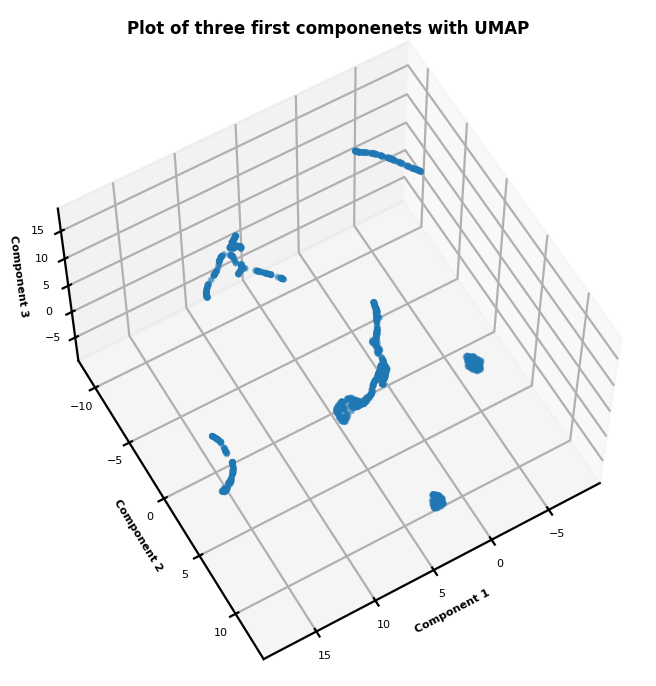

In [ ]:
fig = plt.figure(figsize=(6, 4), dpi=200)
ax = fig.add_subplot(111, projection = "3d" )
ax.view_init(60, 60)
ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], s=2, alpha=0.5)

ax.set_xlabel("Component 1", fontsize=4, labelpad=-10, weight="bold")
ax.tick_params(axis='x', labelsize=4, pad=-3)

ax.set_ylabel("Component 2", fontsize=4, labelpad=-10, weight="bold")
ax.tick_params(axis='y', labelsize=4, pad=-3)

ax.set_zlabel("Component 3", fontsize=4, labelpad=-10, rotation=90, weight="bold")
ax.tick_params(axis='z', labelsize=4, pad=-3)

ax.set_title("Plot of three first componenets with UMAP"  , fontsize=6, loc="center", weight="bold");

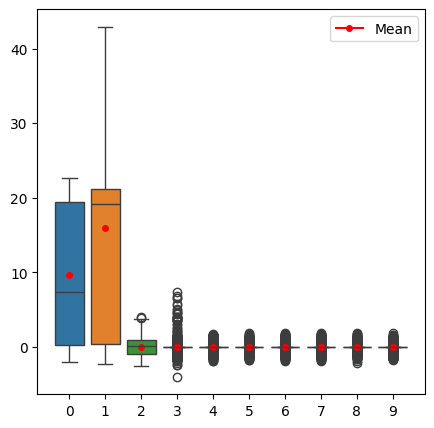

In [ ]:
plt.figure(figsize= (5, 5))
ax = sns.boxplot(data=data_df)
for idx, mean in enumerate(data_df.mean()):
  ax.plot(idx, mean, marker="o", color ="red", markersize=4, label='Mean' if idx==0 else "")

plt.legend()


In [15]:
# To scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_df)
data_scaled.shape

(1000, 10)

Following KMeans clustering will be used, to get better results the appropriate number of clusters must be obtaind. To this Elbow Method, Silhouette score and Davies-Bouldin Index will be used.

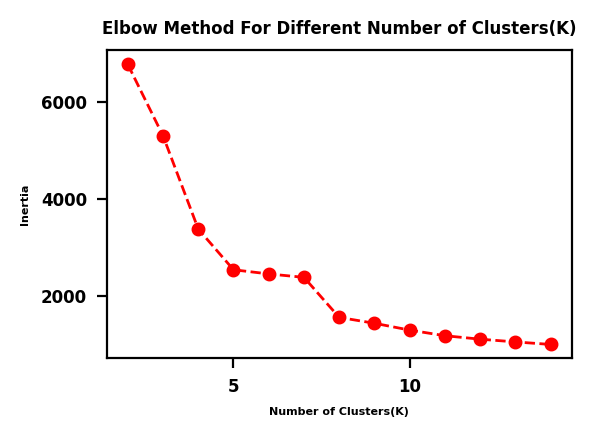

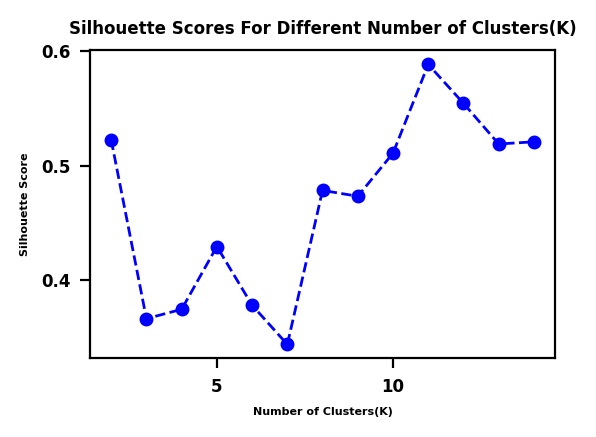

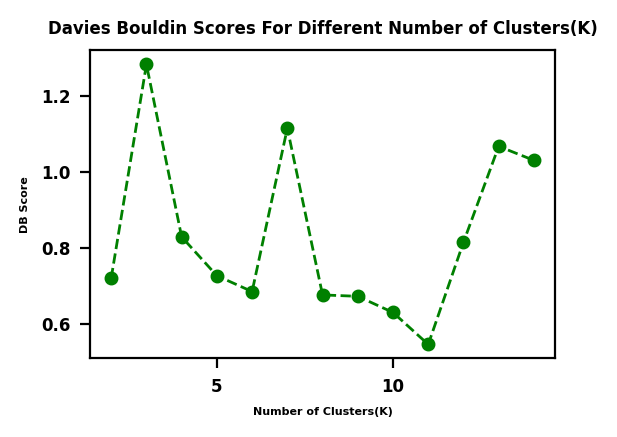

In [16]:
# To obtain the best number of clusters in KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

inertia_val = []
silhouette_scores = []
davies_bouldin_scores = []
for k in range(2, 15):
  kmeans = KMeans(n_clusters = k, random_state = 42)
  labels = kmeans.fit_predict(data_scaled)
  inertia_val.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(data_scaled, labels, metric = 'euclidean'))
  davies_bouldin_scores.append(davies_bouldin_score(data_scaled, labels))

def plot_metrics(score_val, title, ylabel, color):
  plt.figure(figsize = (3, 2), dpi = 200)
  plt.plot(range(2, 15), score_val, "o--", color = color, markersize = 4, linewidth = 1)
  plt.title(title, fontsize = 6, weight = "bold")
  plt.xlabel("Number of Clusters(K)", fontsize = 4, weight = "bold")
  plt.ylabel(ylabel, fontsize = 4, weight = "bold")
  plt.xticks(fontsize = 6, weight = "bold")
  plt.yticks(fontsize = 6, weight = "bold")
  plt.show()

# To plot Elboe Method
plot_metrics(inertia_val, "Elbow Method For Different Number of Clusters(K)", "Inertia", "red")

# To plot Silhouette Score
plot_metrics(silhouette_scores, "Silhouette Scores For Different Number of Clusters(K)", "Silhouette Score", "blue")

# To plot Davies Bouldin Score
plot_metrics(davies_bouldin_scores, "Davies Bouldin Scores For Different Number of Clusters(K)", "DB Score", "green")



Considering 3

As it is shown in diagrams above, Elbow Method suggests that the best number of clusters is 4, but Silhouette and Davies-Bouldin scores indicate the best number is 11. This seems to be a contradiction. This is where Dimensionality Reduction can help, the diagrams which plotted using PCA, t_SNE and UMAP show that the numer of clusters are more than 4, near 11. So the number of clusters preferred is 11.

In [ ]:
kmeans_model = KMeans(n_clusters = 11, random_state = 42)
labels = kmeans_model.fit_predict(data_scaled)
data_df["Label"] = labels
data_df.head()

,0,1,2,3,4,5,6,7,8,9,Label
0,-0.768094,-1.062899,-1.502895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
1,-1.326407,-0.725706,-1.436839,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
2,-0.870501,-0.944614,-0.796163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
3,-1.198228,-0.633996,-1.031985,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
4,-0.581253,-0.839979,-0.762256,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8


Now I want to use DBSCAN for clustering, as you know this algorithm has 2 main tunable parameters, eps and min_samples, following I try to tune these parameters. first, I use k-distance graph for guessing apropriate min_samples and then use different eps values with silhouette and DB-index to find the best eps too.

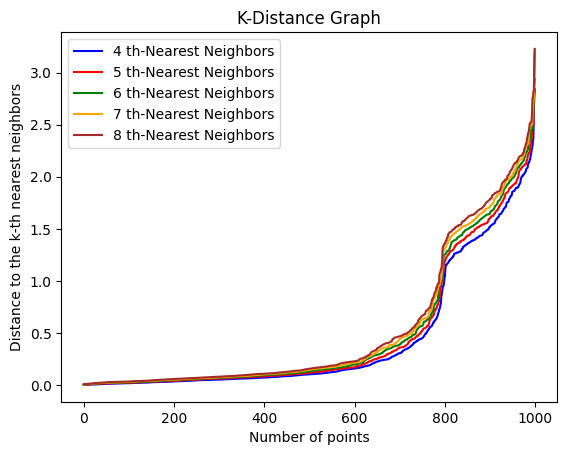

In [ ]:
# To plot k-distance Graph
from sklearn.neighbors import NearestNeighbors
color = ["blue", "red", "green", "orange", "brown"]
for k in range(4, 9):
  k_nearest_neighbors = NearestNeighbors(n_neighbors = k)
  k_nearest_neighbors.fit(data_scaled)
  distances, neighbors = k_nearest_neighbors.kneighbors(data_scaled)
  k_nearest_distances = np.sort(distances[:, k-1])
  plt.title("K-Distance Graph")
  plt.plot(k_nearest_distances, color = color[k-4], label =f"{k} th-Nearest Neighbors" )
  plt.xlabel("Number of points")
  plt.ylabel("Distance to the k-th nearest neighbors")
  plt.legend(fontsize = 10)
plt.show()




Considering the plot above, I choose 6 for min_samples and eps in the range[0.2, 0.75]

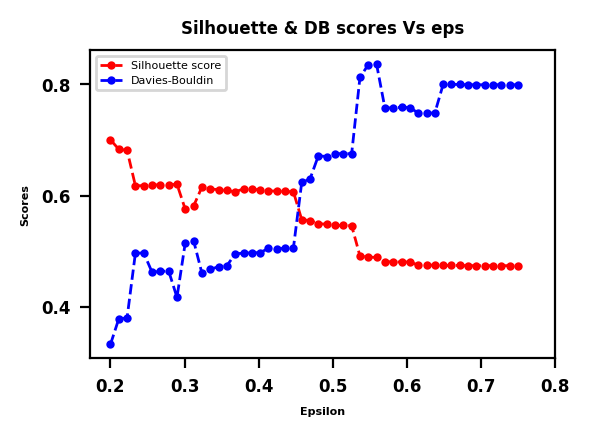

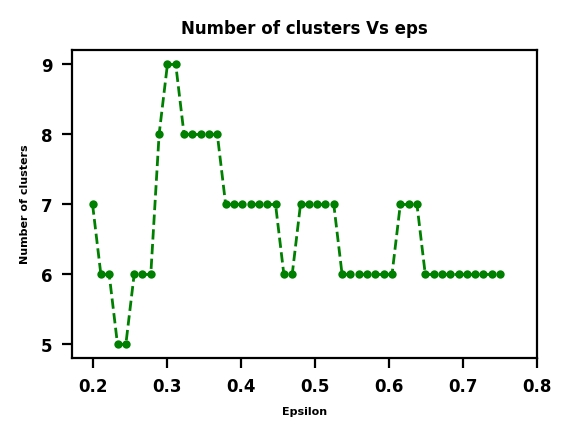

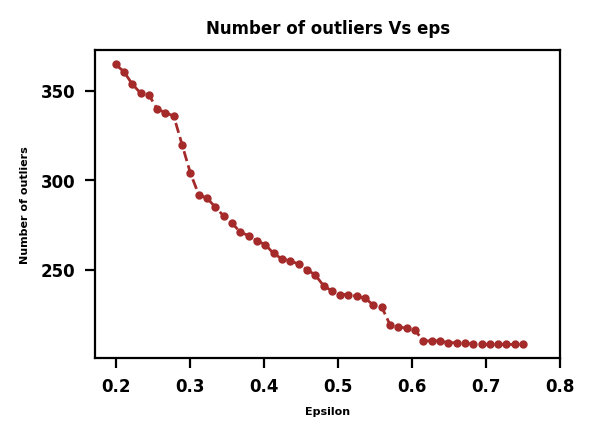

In [ ]:
# To find the best value foe epsilon
from sklearn.cluster import DBSCAN
silhouette_scores = []
davies_bouldin_scores = []
n_clusters = []
n_outlier = []
# Choose several points to epsilon
for eps in np.linspace(0.2, 0.75, 50):
  dbscan = DBSCAN(eps = eps, min_samples = 6)
  labels = dbscan.fit_predict(data_scaled)
  # Selecting the non outlier indices
  non_outlier_idx = labels != -1
  # To select points which are not outlier
  clustered_data = data_scaled[non_outlier_idx]
  # To find the number of clusters
  n_clusters.append(len(np.unique(labels[non_outlier_idx])))
  # To find the number of outliers
  n_outlier.append(int(np.sum(labels == -1)))
  # To calculate Silhouette scores
  silhouette_scores.append(silhouette_score(clustered_data, labels[non_outlier_idx], metric = 'euclidean'))
  # To calculate davies-bouldin scores
  davies_bouldin_scores.append(davies_bouldin_score(clustered_data, labels[non_outlier_idx]))


plt.figure(figsize = (3, 2), dpi = 200)
desired_xticks = np.linspace(.2, .8, 7)
# To plot Silhouette and davies-bouldin Vs eps
plt.plot(np.linspace(0.2, 0.75, 50), silhouette_scores, "o--", color = "red", markersize = 2, linewidth = 1, label = "Silhouette score")
plt.plot(np.linspace(0.2, 0.75, 50), davies_bouldin_scores, "o--", color = "blue", markersize = 2, linewidth = 1, label = "Davies-Bouldin")
plt.title("Silhouette & DB scores Vs eps", fontsize = 6, weight = "bold")
plt.xlabel("Epsilon", fontsize = 4, weight = "bold")
plt.ylabel("Scores", fontsize = 4, weight = "bold")
plt.xticks(desired_xticks, fontsize = 6, weight = "bold")
plt.yticks(fontsize = 6, weight = "bold")
plt.legend(fontsize = 4)
plt.show()

# To plot number of clusters Vs eps
plt.figure(figsize = (3, 2), dpi = 200)
plt.plot(np.linspace(0.2, 0.75, 50), n_clusters, "o--", color = "green", markersize = 2, linewidth = 1)
plt.title("Number of clusters Vs eps", fontsize = 6, weight = "bold")
plt.xlabel("Epsilon", fontsize = 4, weight = "bold")
plt.ylabel("Number of clusters", fontsize = 4, weight = "bold")
plt.xticks(desired_xticks,fontsize = 6, weight = "bold")
plt.yticks(fontsize = 6, weight = "bold")
plt.show()

# To plot number of outliers Vs eps
plt.figure(figsize = (3, 2), dpi = 200)
plt.plot(np.linspace(0.2, 0.75, 50), n_outlier, "o--", color = "brown", markersize = 2, linewidth = 1)
plt.title("Number of outliers Vs eps", fontsize = 6, weight = "bold")
plt.xlabel("Epsilon", fontsize = 4, weight = "bold")
plt.ylabel("Number of outliers", fontsize = 4, weight = "bold")
plt.xticks(desired_xticks,fontsize = 6, weight = "bold")
plt.yticks(fontsize = 6, weight = "bold")
plt.show()


In [ ]:
# To find the non outlier samples, outliers obtained from DBSCAN
data_df = pd.read_csv("challenge.txt", delimiter='\t', header=None)
dbscan = DBSCAN(eps = 0.32, min_samples = 6)
labels = dbscan.fit_predict(data_scaled)
non_outlier_idx = labels != -1
df_non_outlier_samples = data_df[non_outlier_idx]
df_non_outlier_samples.head()

,0,1,2,3,4,5,6,7,8,9
0,-0.768094,-1.062899,-1.502895,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.326407,-0.725706,-1.436839,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.870501,-0.944614,-0.796163,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.198228,-0.633996,-1.031985,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.581253,-0.839979,-0.762256,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Considering plots above, the appropriate value for epsilon may be 0.32. So the dataset has been devided to 8 clusters.
################### AFTER heirarchical  i must compare all algorithm. Kmeans is best for spherical and roughly equal size data but DBSCAN is more appropriate for arbitrary shape data. as we saw in 3 dplots this dataset is not spherical

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [22]:
data_df_scaled = scaler.fit_transform(data_df)
data_df_scaled = pd.DataFrame(data_df_scaled, columns = data_df.columns)
data_df_scaled.head()

,0,1,2,3,4,5,6,7,8,9
0,0.049834,0.028081,0.157671,0.350608,0.508584,0.483012,0.503305,0.511338,0.529883,0.491894
1,0.027223,0.035530,0.167716,0.350608,0.508584,0.483012,0.503305,0.511338,0.529883,0.491894
2,0.045687,0.030694,0.265139,0.350608,0.508584,0.483012,0.503305,0.511338,0.529883,0.491894
3,0.032414,0.037556,0.229280,0.350608,0.508584,0.483012,0.503305,0.511338,0.529883,0.491894
4,0.057401,0.033006,0.270296,0.350608,0.508584,0.483012,0.503305,0.511338,0.529883,0.491894


/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


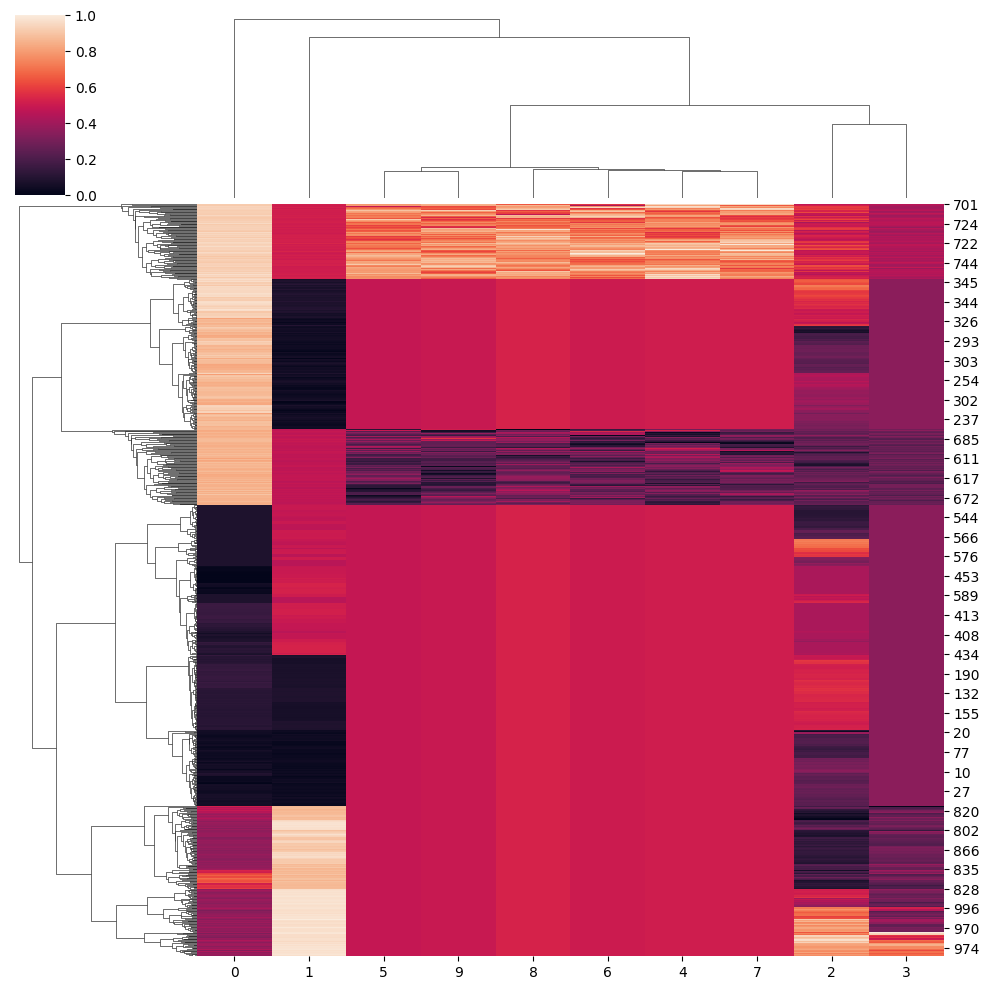

In [ ]:
# removeeeeeeeeeeeeeeeeeee
sns.clustermap(data=data_df_scaled)

In [23]:
from sklearn.cluster import AgglomerativeClustering

In [24]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy

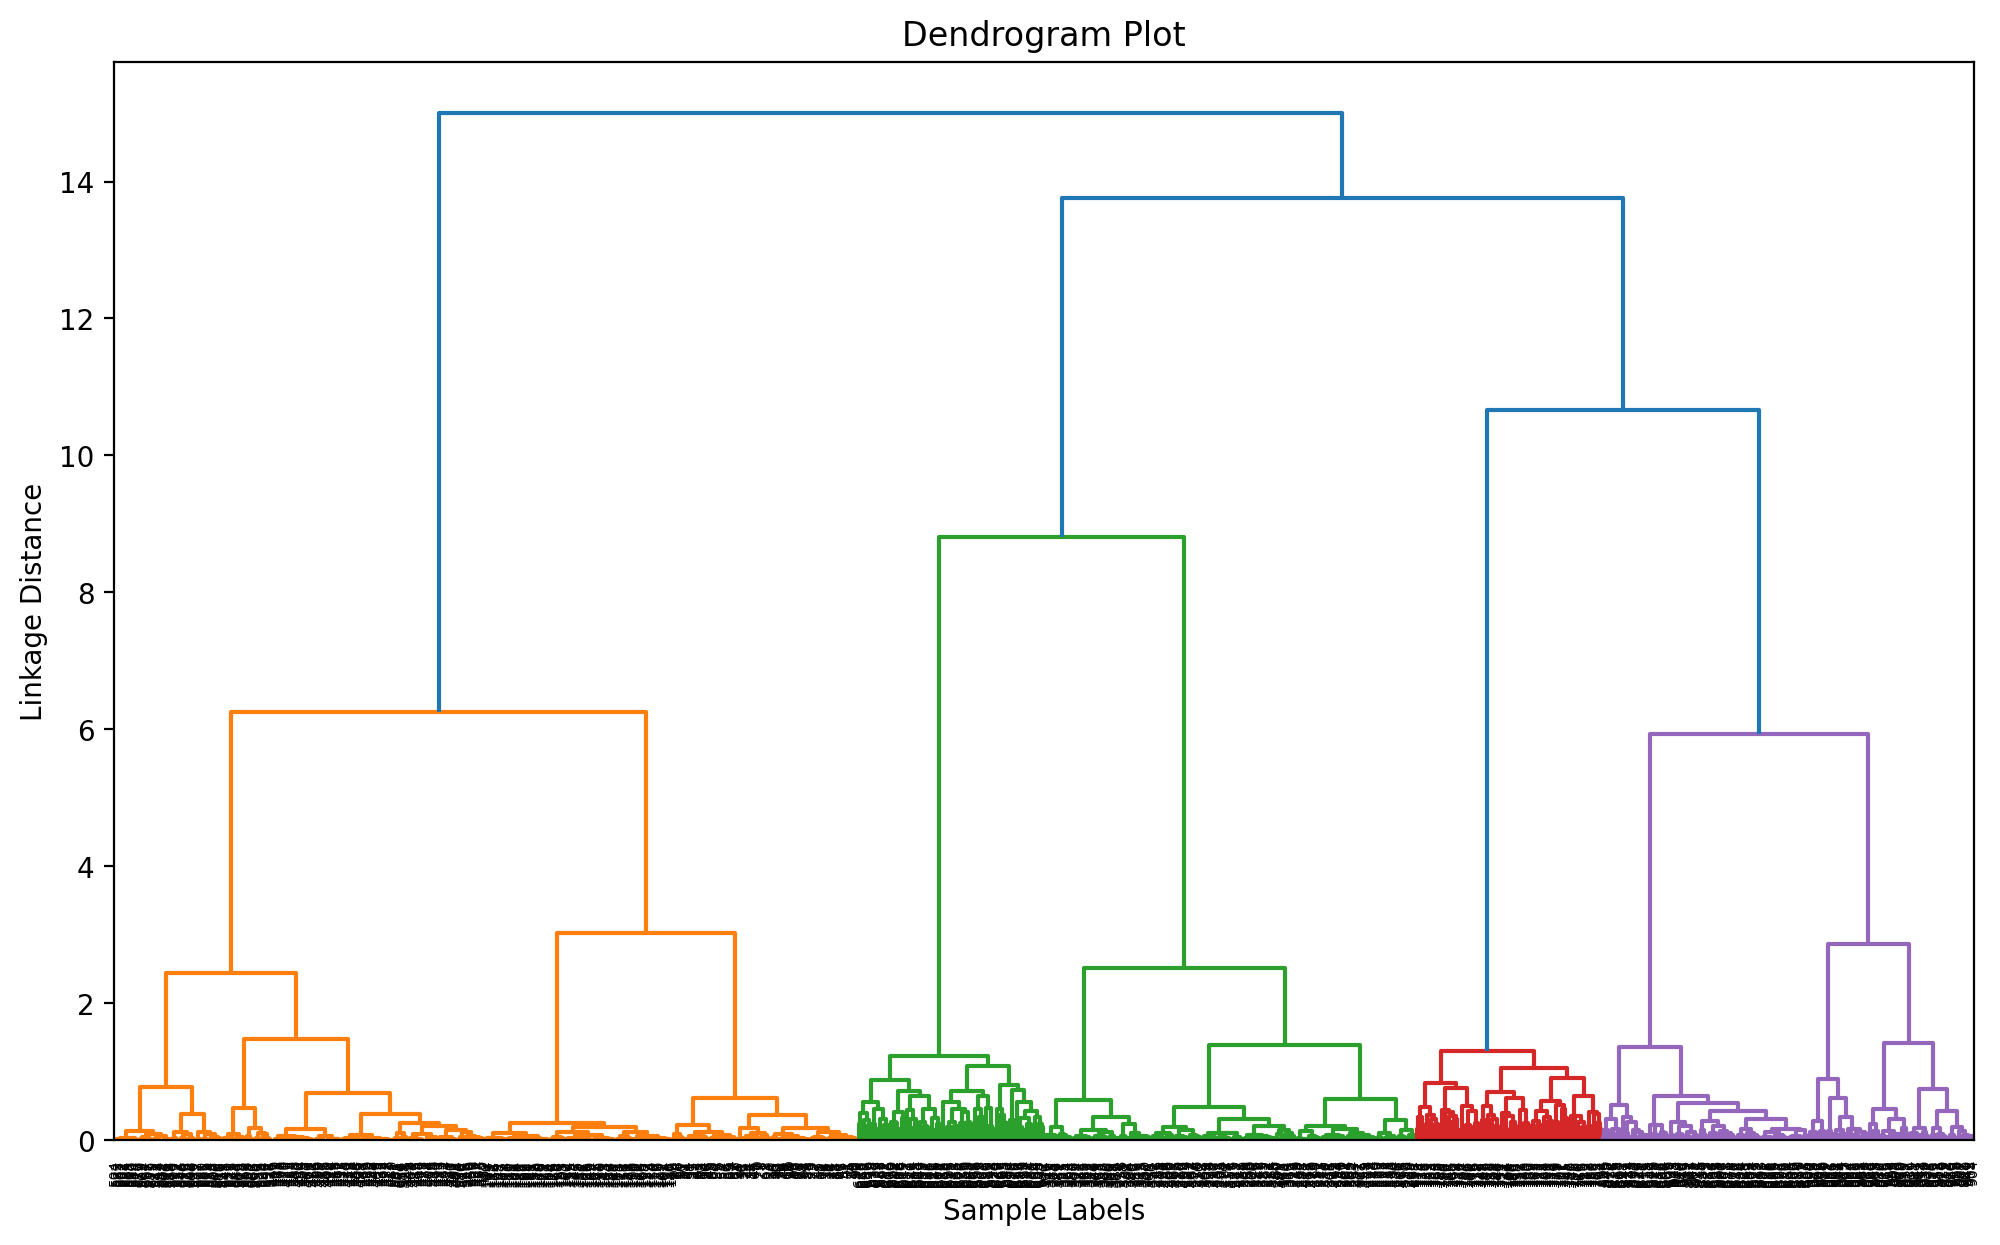

In [25]:
# To calculate Linkage Matrix for all clusters
linkage_matrix = hierarchy.linkage(data_df_scaled, method='ward')

# To plot dendrogram
plt.figure(figsize=(12, 7), dpi = 200)
dendrogram = hierarchy.dendrogram(linkage_matrix)
plt.title("Dendrogram Plot")
plt.xlabel("Sample Labels")
plt.ylabel("Linkage Distance")
plt.show()

The dendrogram of agglomerative clustering is shown above, as it is clear to find the best number of clusters some several numbers will be choosen and the appropriate scores will be calculated for them.

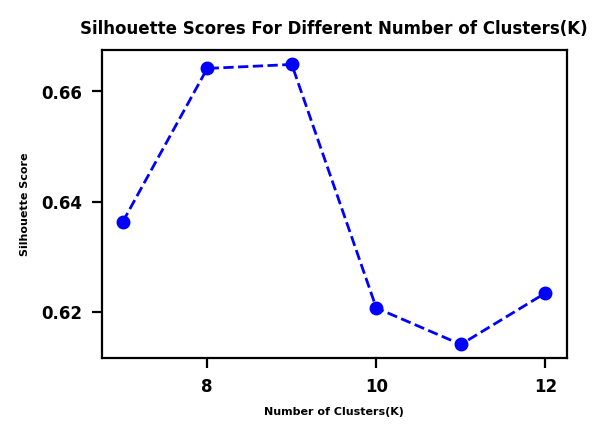

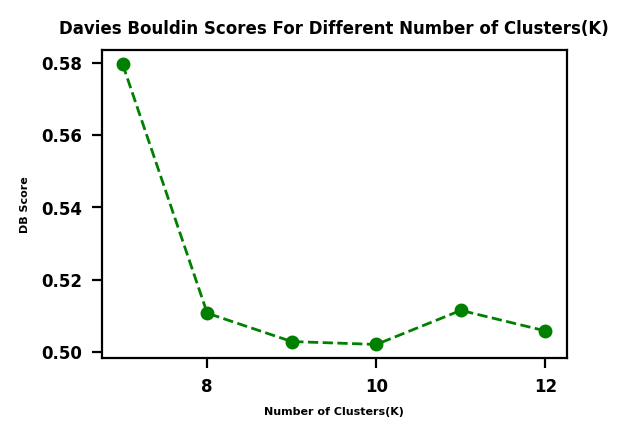

In [26]:
silhouette_scores = []
davies_bouldin_scores = []
for n_cluster in range(7, 13):
  model = AgglomerativeClustering(n_clusters=n_cluster,distance_threshold=None)
  labels = model.fit_predict(data_df_scaled)
  silhouette_scores.append(silhouette_score(data_df_scaled, labels, metric = 'euclidean'))
  davies_bouldin_scores.append(davies_bouldin_score(data_df_scaled, labels))

def plot_metrics(score_val, title, ylabel, color):
  plt.figure(figsize = (3, 2), dpi = 200)
  plt.plot(range(7, 13), score_val, "o--", color = color, markersize = 4, linewidth = 1)
  plt.title(title, fontsize = 6, weight = "bold")
  plt.xlabel("Number of Clusters(K)", fontsize = 4, weight = "bold")
  plt.ylabel(ylabel, fontsize = 4, weight = "bold")
  plt.xticks(fontsize = 6, weight = "bold")
  plt.yticks(fontsize = 6, weight = "bold")
  plt.show()

# To plot Silhouette Score
plot_metrics(silhouette_scores, "Silhouette Scores For Different Number of Clusters(K)", "Silhouette Score", "blue")

# To plot Davies Bouldin Score
plot_metrics(davies_bouldin_scores, "Davies Bouldin Scores For Different Number of Clusters(K)", "DB Score", "green")



Two plots above, suggest 8 or 9 to the number of clusters. Following, to more clarification the number of samples per clusters Vs number of data clusters will be plotted.

/tmp/ipython-input-45-243797472.py:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plt.plot(pd.value_counts(pd.Series(labels)).sort_index(), marker = marker[i], ls = "--", color = color[i], markersize=8, label=f"n_cluster = {n_cluster}");
/tmp/ipython-input-45-243797472.py:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plt.plot(pd.value_counts(pd.Series(labels)).sort_index(), marker = marker[i], ls = "--", color = color[i], markersize=8, label=f"n_cluster = {n_cluster}");


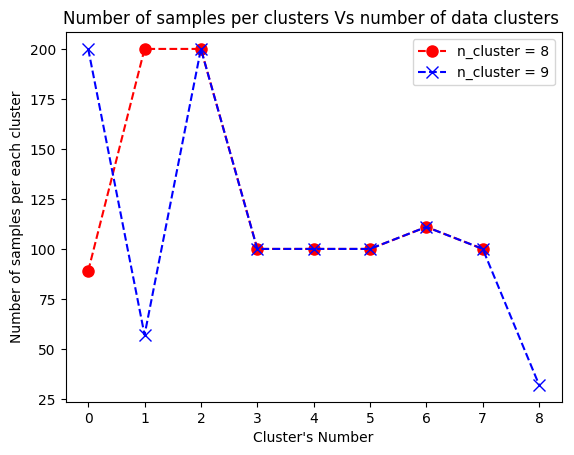

In [45]:
color = ["red", "blue"]
marker = ["o", "x"]
i = 0
for n_cluster in range(8, 10):
  model = AgglomerativeClustering(n_clusters=n_cluster,distance_threshold=None)
  labels = model.fit_predict(data_df_scaled)
  plt.plot(pd.value_counts(pd.Series(labels)).sort_index(), marker = marker[i], ls = "--", color = color[i], markersize=8, label=f"n_cluster = {n_cluster}");
  plt.title("Number of samples per clusters Vs number of data clusters ")
  plt.xlabel("Cluster's Number")
  plt.ylabel("Number of samples per each cluster")
  plt.legend()
  i += 1


As it is shown above dividing data to 8 clusters resulted in clusters with more samples, which is more desired.

/tmp/ipython-input-70-2652172447.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plt.plot(pd.value_counts(pd.Series(labels)).sort_index(), "o--")


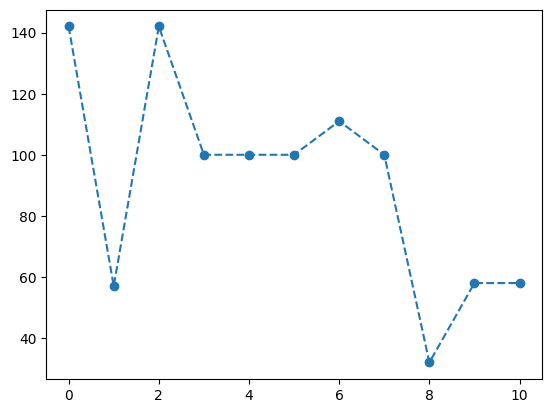

In [ ]:
labels = model.fit_predict(data_df_scaled)
plt.plot(pd.value_counts(pd.Series(labels)).sort_index(), "o--")

In [ ]:
# start here
# By removing the outlier samples which are obtained from DBSCAN, the Agglomerative clustering is used for clustering
from sklearn.cluster import AgglomerativeClustering

In [ ]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled_non_outlier = scaler.fit_transform(df_non_outlier_samples)

# To convert the array to DataFrame
df_data_non_outlier = pd.DataFrame(data_scaled_non_outlier, columns = df_non_outlier_samples.columns)
len(df_data_non_outlier)

708

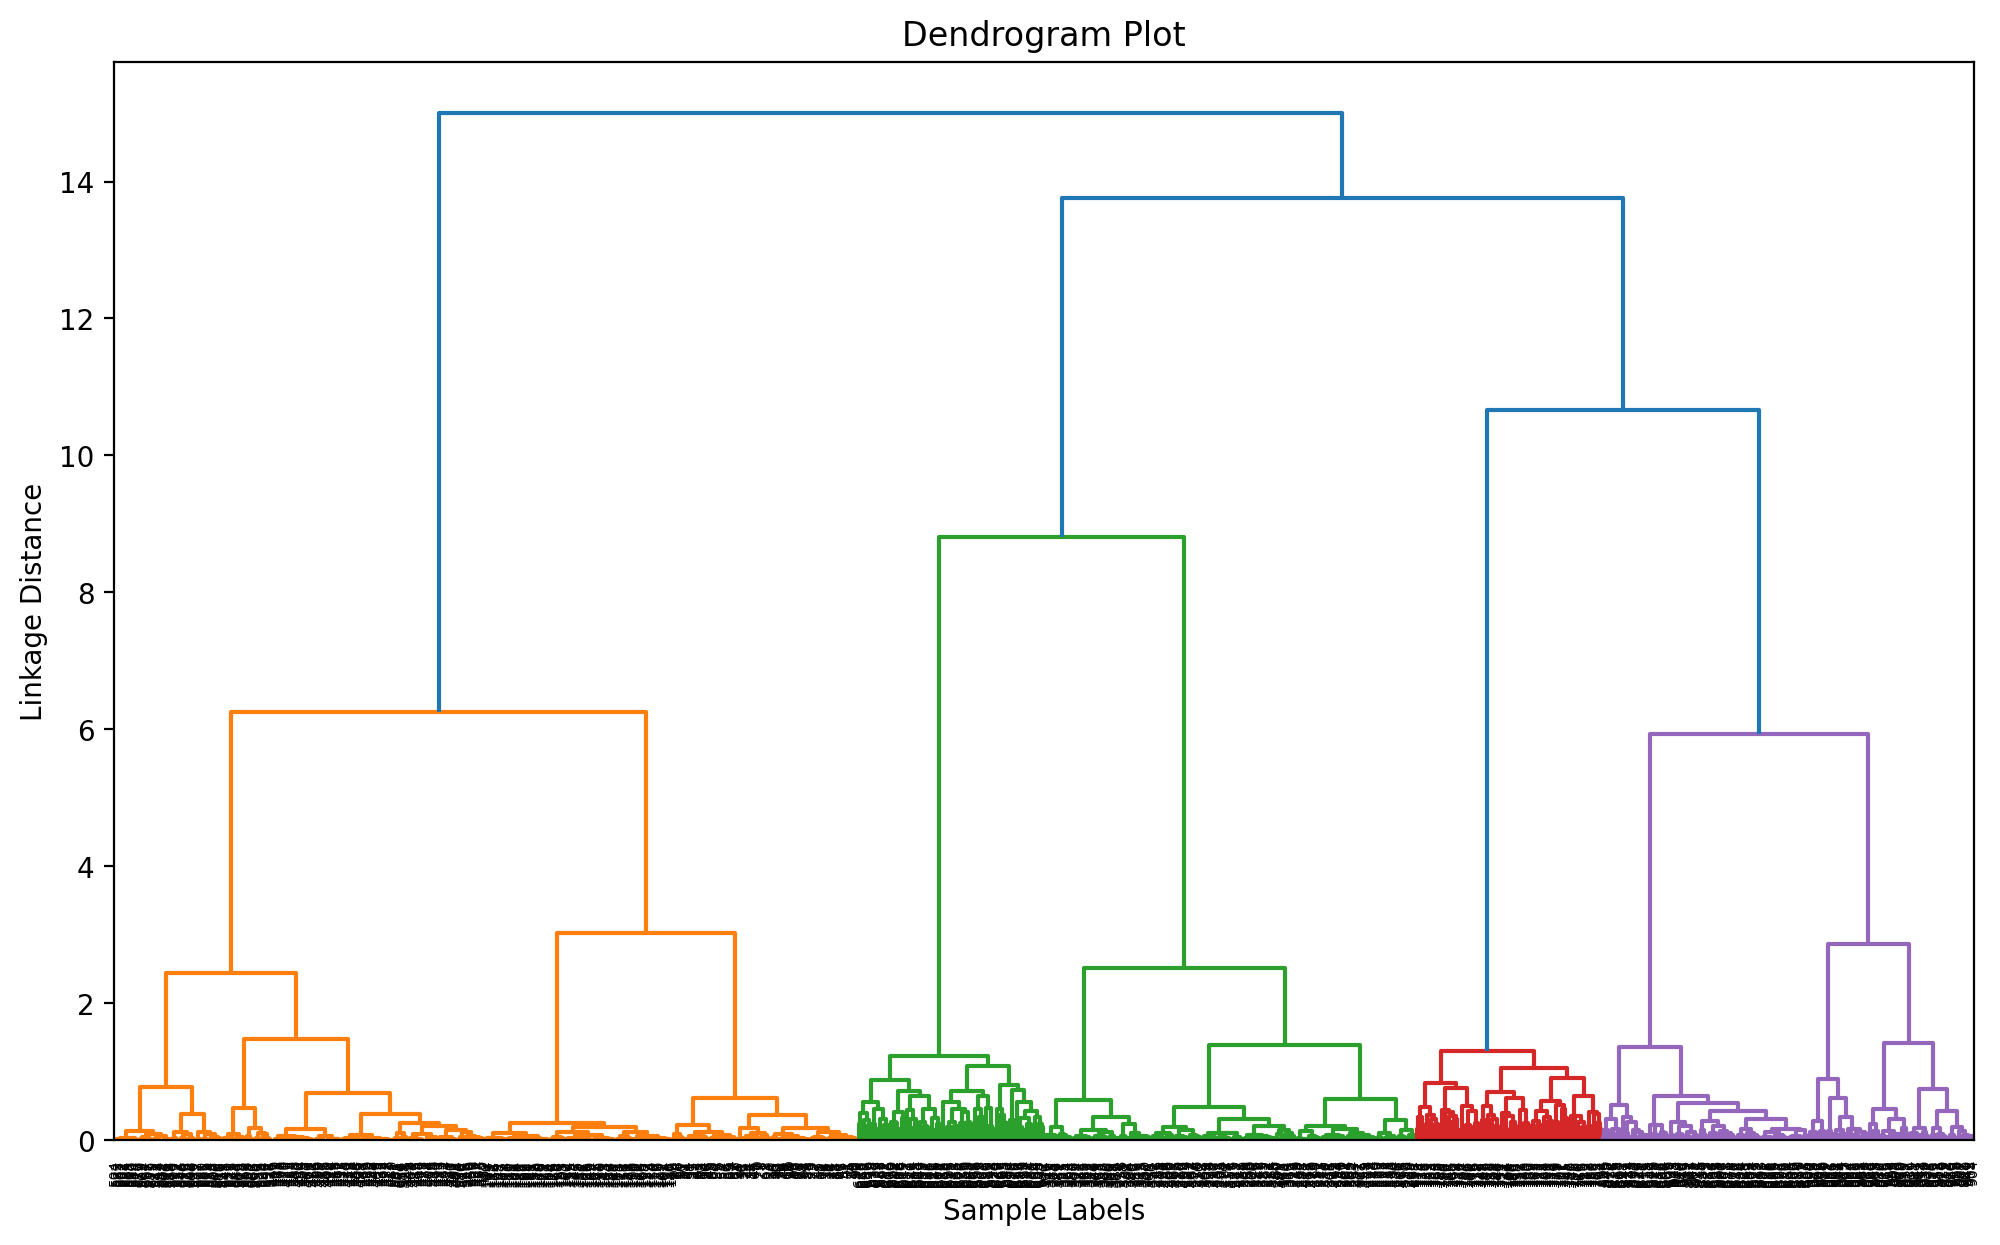

In [ ]:
# To calculate Linkage Matrix for non outlier samples
linkage_matrix = hierarchy.linkage(data_df_scaled, method='ward')

# To plot dendrogram
plt.figure(figsize=(12, 7), dpi = 200)
dendrogram = hierarchy.dendrogram(linkage_matrix)
plt.title("Dendrogram Plot")
plt.xlabel("Sample Labels")
plt.ylabel("Linkage Distance")
plt.show()

As it is shown the plot above, choosing linkage distance equals 2 may result in good clustering

In [ ]:
model = AgglomerativeClustering(n_clusters=11, distance_threshold=None)
labels = model.fit_predict(df_data_non_outlier)

In [ ]:
pd.value_counts(pd.Series(labels))

/tmp/ipython-input-24-2311452549.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(pd.Series(labels))


,count
7,115
5,100
3,99
4,75
10,74
6,64
2,62
1,58
9,27
0,27
